In [2]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# =========================================================
# LOAD CSV DATA
# =========================================================

baca = pd.read_csv("baca_results.csv")
aca = pd.read_csv("aca_results.csv")

# =========================================================
# CREATE FIGURE
# =========================================================

fig = go.Figure()

# =========================================================
# BACA ANALYSIS
# =========================================================

d_values = sorted(baca["d"].unique())

for d in d_values:

    # -----------------------------------------------------
    # FILTER d
    # -----------------------------------------------------

    df = baca[baca["d"] == d].copy()

    # -----------------------------------------------------
    # GROUP BY n
    #
    # We now compute robust statistics because
    # every repeat is stored individually.
    # -----------------------------------------------------

    grouped = (
        df.groupby("n")
        .agg({
            "elapsed": ["median", "mean", "std"],
            "rank": ["median", "mean", "std"],
            "T_over_rank": ["median", "mean", "std"],
            "T_over_nk": ["median", "mean", "std"],
            "T_over_nk2": ["median", "mean", "std"]
        })
    )

    # flatten multi-index columns
    grouped.columns = [
        "_".join(col).strip()
        for col in grouped.columns.values
    ]

    grouped = grouped.reset_index()

    # -----------------------------------------------------
    # USE MEDIAN T/rank
    #
    # Median is MUCH more stable for randomized
    # algorithms than mean.
    # -----------------------------------------------------

    x = grouped["n"].to_numpy()

    y = grouped["T_over_rank_median"].to_numpy()

    y_std = grouped["T_over_rank_std"].to_numpy()

    # -----------------------------------------------------
    # RAW MEASUREMENTS (faint)
    # -----------------------------------------------------

    fig.add_trace(
        go.Scatter(
            x=df["n"],
            y=df["T_over_rank"],
            mode='markers',
            opacity=0.25,
            marker=dict(size=5),
            name=f'BACA d={d} raw samples'
        )
    )

    # -----------------------------------------------------
    # MEDIAN + ERROR BARS
    # -----------------------------------------------------

    fig.add_trace(
        go.Scatter(
            x=x,
            y=y,
            mode='markers+lines',
            error_y=dict(
                type='data',
                array=y_std,
                visible=True
            ),
            marker=dict(size=10),
            name=f'BACA d={d} median'
        )
    )

    # -----------------------------------------------------
    # LINEAR FIT TO MEDIAN
    # -----------------------------------------------------

    coeff_lin = np.polyfit(x, y, 1)

    fit_lin = np.poly1d(coeff_lin)

    x_fit = np.linspace(
        np.min(x),
        np.max(x),
        300
    )

    fig.add_trace(
        go.Scatter(
            x=x_fit,
            y=fit_lin(x_fit),
            mode='lines',
            name=f'BACA d={d} linear fit'
        )
    )

    # -----------------------------------------------------
    # QUADRATIC FIT TO MEDIAN
    # -----------------------------------------------------

    coeff_quad = np.polyfit(x, y, 2)

    fit_quad = np.poly1d(coeff_quad)

    fig.add_trace(
        go.Scatter(
            x=x_fit,
            y=fit_quad(x_fit),
            mode='lines',
            visible='legendonly',
            name=f'BACA d={d} quadratic fit'
        )
    )

    # -----------------------------------------------------
    # PRINT STATS
    # -----------------------------------------------------

    print("\n================================================")
    print(f"BACA d = {d}")
    print("================================================")

    print("\nMedian T/rank values:")
    print(grouped[["n", "T_over_rank_median"]])

    print("\nStd(T/rank):")
    print(grouped[["n", "T_over_rank_std"]])

    print("\nLinear coefficients:")
    print(coeff_lin)

    print("\nQuadratic coefficients:")
    print(coeff_quad)

# =========================================================
# ACA ANALYSIS
# =========================================================

grouped_aca = (
    aca.groupby("n")
    .agg({
        "elapsed": ["median", "mean", "std"],
        "rank": ["median", "mean", "std"],
        "T_over_rank": ["median", "mean", "std"],
        "T_over_nk": ["median", "mean", "std"],
        "T_over_nk2": ["median", "mean", "std"]
    })
)

grouped_aca.columns = [
    "_".join(col).strip()
    for col in grouped_aca.columns.values
]

grouped_aca = grouped_aca.reset_index()

# ---------------------------------------------------------
# MEDIAN DATA
# ---------------------------------------------------------

x_aca = grouped_aca["n"].to_numpy()

y_aca = grouped_aca["T_over_rank_median"].to_numpy()

y_std_aca = grouped_aca["T_over_rank_std"].to_numpy()

# ---------------------------------------------------------
# RAW ACA SAMPLES
# ---------------------------------------------------------

fig.add_trace(
    go.Scatter(
        x=aca["n"],
        y=aca["T_over_rank"],
        mode='markers',
        opacity=0.25,
        marker=dict(size=5),
        name='ACA raw samples'
    )
)

# ---------------------------------------------------------
# ACA MEDIAN + ERROR BARS
# ---------------------------------------------------------

fig.add_trace(
    go.Scatter(
        x=x_aca,
        y=y_aca,
        mode='markers+lines',
        error_y=dict(
            type='data',
            array=y_std_aca,
            visible=True
        ),
        marker=dict(size=10),
        name='ACA median'
    )
)

# ---------------------------------------------------------
# ACA LINEAR FIT
# ---------------------------------------------------------

coeff_lin_aca = np.polyfit(x_aca, y_aca, 1)

fit_lin_aca = np.poly1d(coeff_lin_aca)

x_fit_aca = np.linspace(
    np.min(x_aca),
    np.max(x_aca),
    300
)

fig.add_trace(
    go.Scatter(
        x=x_fit_aca,
        y=fit_lin_aca(x_fit_aca),
        mode='lines',
        name='ACA linear fit'
    )
)

# ---------------------------------------------------------
# ACA QUADRATIC FIT
# ---------------------------------------------------------

coeff_quad_aca = np.polyfit(x_aca, y_aca, 2)

fit_quad_aca = np.poly1d(coeff_quad_aca)

fig.add_trace(
    go.Scatter(
        x=x_fit_aca,
        y=fit_quad_aca(x_fit_aca),
        mode='lines',
        visible='legendonly',
        name='ACA quadratic fit'
    )
)

# =========================================================
# PRINT ACA STATS
# =========================================================

print("\n================================================")
print("ACA")
print("================================================")

print("\nMedian T/rank values:")
print(grouped_aca[["n", "T_over_rank_median"]])

print("\nStd(T/rank):")
print(grouped_aca[["n", "T_over_rank_std"]])

print("\nLinear coefficients:")
print(coeff_lin_aca)

print("\nQuadratic coefficients:")
print(coeff_quad_aca)

# =========================================================
# LAYOUT
# =========================================================

fig.update_layout(
    title="ACA vs BACA Runtime Scaling",
    xaxis_title="Matrix size n",
    yaxis_title="Median(T / rank)",
    template="plotly_white",
    hovermode="closest",
    width=1400,
    height=800
)

# =========================================================
# SHOW
# =========================================================

fig.show()



BACA d = 2

Median T/rank values:
       n  T_over_rank_median
0   1100            0.003155
1   1200            0.003729
2   1300            0.004789
3   1400            0.005448
4   1500            0.006874
5   1600            0.006824
6   1700            0.006439
7   1800            0.007934
8   1900            0.009623
9   2000            0.010643
10  2100            0.011896
11  2200            0.011696
12  2300            0.013792
13  2400            0.013597
14  2500            0.020433
15  2600            0.019857
16  2700            0.021484
17  2800            0.018668
18  2900            0.021682
19  3000            0.024506

Std(T/rank):
       n  T_over_rank_std
0   1100         0.000264
1   1200         0.000715
2   1300         0.001489
3   1400         0.001528
4   1500         0.001624
5   1600         0.001915
6   1700         0.001552
7   1800         0.001288
8   1900         0.002238
9   2000         0.002820
10  2100         0.002164
11  2200         0.001712
12  

In [3]:
import pandas as pd
import plotly.graph_objects as go
import numpy as np

# =========================================================
# USER SETTINGS
# =========================================================

# Choose which BACA d-values to plot
selected_d = [4, 16]

# Plot ACA?
plot_aca = True

# Plot SVD?
plot_svd = True

# =========================================================
# LOAD DATA
# =========================================================

df = pd.read_csv(
    "frobenius_norms.csv",
    names=["method", "d", "start", "rank", "frob"],
    header=0
)

df_svd = pd.read_csv(
    "frobenius_norms_svd.csv",
    names=["rank", "frob"],
    header=0
)

# =========================================================
# FORCE NUMERIC TYPES
# =========================================================

df["d"] = pd.to_numeric(df["d"])
df["start"] = pd.to_numeric(df["start"])
df["rank"] = pd.to_numeric(df["rank"])
df["frob"] = pd.to_numeric(df["frob"])

df_svd["rank"] = pd.to_numeric(df_svd["rank"])
df_svd["frob"] = pd.to_numeric(df_svd["frob"])

# =========================================================
# SORT
# =========================================================

df = df.sort_values(["method", "d", "rank"])

# =========================================================
# CREATE FIGURE
# =========================================================

fig = go.Figure()

# =========================================================
# ACA
# =========================================================

if plot_aca:

    aca = df[df["method"] == "ACA"]

    fig.add_trace(
        go.Scatter(
            x=aca["rank"],
            y=aca["frob"],
            mode="lines+markers",
            name="ACA"
        )
    )

# =========================================================
# BACA
# =========================================================

baca = df[
    (df["method"] == "BACA") &
    (df["d"].isin(selected_d))
]

for d in sorted(baca["d"].unique()):

    sub = baca[baca["d"] == d]

    fig.add_trace(
        go.Scatter(
            x=sub["rank"],
            y=sub["frob"],
            mode="lines+markers",
            name=f"BACA d={d}"
        )
    )

# =========================================================
# SVD
# =========================================================

if plot_svd:

    fig.add_trace(
        go.Scatter(
            x=df_svd["rank"],
            y=df_svd["frob"],
            mode="lines+markers",
            name="SVD"
        )
    )

# =========================================================
# LAYOUT
# =========================================================

fig.update_layout(
    title="Frobenius Norm",
    xaxis_title="Rank",
    yaxis_title="Frobenius norm",
    template="plotly_white",
    hovermode="x unified",
    width=1200,
    height=700
)

# =========================================================
# LOG SCALE
# =========================================================



fig.update_yaxes(
    type="log",
   # shows 1e-12 to 1e0
)

fig.write_image(
    "frobenius_norm.svg",
    width=1200,
    height=700
)
# =========================================================
# SHOW
# =========================================================

fig.show(
    config={
        "scrollZoom": True
    }
)


In [4]:
import json
import pandas as pd
from pathlib import Path

results_dir = Path("results")

files = list(results_dir.glob("*.json"))
print(len(files))

61


In [5]:
experiments = []

for file in files:
    with open(file) as f:
        data = json.load(f)

    experiments.append({
        "file": file.name,
        "timestamp": data.get("timestamp"),
        "method": data.get("method"),
        "test_function": data.get("test_function")
    })

exp_df = pd.DataFrame(experiments)
exp_df

,file,timestamp,method,test_function
0,2026-07-17_14-56-36.json,results/2026-07-17_14-56-36.json,ACA,test_function_gaussian
1,2026-07-17_15-13-00.json,results/2026-07-17_15-13-00.json,BACA,test_function_gaussian
2,2026-07-17_15-21-42.json,results/2026-07-17_15-21-42.json,BACA,test_function_gaussian
3,2026-07-17_15-26-21.json,results/2026-07-17_15-26-21.json,BACA,test_function_gaussian
4,2026-07-17_15-28-37.json,results/2026-07-17_15-28-37.json,BACA,test_function_gaussian
...,...,...,...,...
56,2026-08-03_01-07-58.json,results/2026-08-03_01-07-58.json,HBACA,test_function_gaussian
57,2026-08-03_01-12-45.json,results/2026-08-03_01-12-45.json,HBACA,test_function_gaussian
58,2026-08-03_08-56-02.json,results/2026-08-03_08-56-02.json,BACA,test_function_log
59,2026-08-03_10-15-51.json,results/2026-08-03_10-15-51.json,BACA,test_function_gaussian


In [6]:
runtime_rows = []

for file in files:
    with open(file) as f:
        data = json.load(f)

    if "runtime_benchmark" not in data:
        continue

    method = data["method"]

    for case in data["runtime_benchmark"]["cases"]:

        agg = case["aggregated_runs"]

        runtime_rows.append({
            "method": method,
            "n": case["n"],
            "rows": case["rows"],
            "cols": case["cols"],
            "avg_time": agg["avg_time"],
            "avg_rank": agg["avg_rank"]
        })

runtime_df = pd.DataFrame(runtime_rows)
runtime_df
%pip install kaleido

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib import cm, colors
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from matplotlib.patches import Rectangle
from matplotlib.transforms import Affine2D
import ipywidgets as widgets
from IPython.display import display, clear_output
from plotly.subplots import make_subplots
from collections import defaultdict


# =====================================================
# FIND FILES
# =====================================================

results_dir = Path("results")
files = sorted(results_dir.glob("*.json"))

if not files:
    raise ValueError("No JSON files found")

# =====================================================
# BENCHMARK TYPE
# =====================================================

def get_benchmark_type(data):

    if "runtime_benchmark" in data:
        return "runtime"

    if "residual_benchmark" in data:
        return "residual"
    if "hbaca_residual_test" in data:
        return "hbaca"
    return "unknown"


# =====================================================
# BUILD FILE LABELS
# =====================================================

file_meta = {}

for f in files:

    try:

        with open(f) as fp:
            data = json.load(fp)

        method = data.get("method", "?")

        if "runtime_benchmark" in data:

            runtime = data["runtime_benchmark"]

            eps = runtime.get("epsilon", "?")
            repeats = runtime.get("repeats", "?")

            d = data.get("d", "?")
            L = data.get("L", "?")

            nvals = [
                c.get("n")
                for c in runtime.get("cases", [])
            ]

            if nvals:
                nstr = f"{min(nvals)}–{max(nvals)}"
            else:
                nstr = "?"

            label = (
                f"[RUNTIME] "
                f"{method:6s} "
                f"d={d} "
                f"L={L} "
                f"eps={eps} "
                f"rep={repeats} "
                f"n=[{nstr}] "
                f"{f.name}"
            )

        elif "residual_benchmark" in data:

            residual = data["residual_benchmark"]

            eps = residual.get("epsilon", "?")

            label = (
                f"[RESIDUAL] "
                f"{method:6s} "
                f"eps={eps} "
                f"{f.name}"
            )
        elif "hbaca_residual_test" in data:

            label = (
                f"[HBACA] "
                f"{method:6s} "
                f"{f.name}"
            )
        else:

            label = f"[UNKNOWN] {f.name}"

    except Exception:

        label = f"[BROKEN] {f.name}"

    file_meta[f] = label


# =====================================================
# CHECKBOXES
# =====================================================

checkboxes = []

for f in files:

    cb = widgets.Checkbox(
        value=False,
        description=file_meta[f],
        indent=False,
        layout=widgets.Layout(width="95%")
    )

    checkboxes.append(cb)

show_std = widgets.Checkbox(
    value=True,
    description="Show std"
)

show_medians = widgets.Checkbox(
    value=True,
    description="Show median lines"
)

plot_button = widgets.Button(
    description="Plot",
    button_style="success"
)

select_all = widgets.Button(
    description="Select All"
)

clear_all = widgets.Button(
    description="Clear"
)
save_fig1 = widgets.Button(
    description="Save Figure 1",
    button_style="info",
    icon="save"
)

save_fig2 = widgets.Button(
    description="Save Figure 2",
    button_style="info",
    icon="save"
)

fig1_name = widgets.Text(
    value="figure1",
    description="Figure 1:",
    layout=widgets.Layout(width="300px")
)

fig2_name = widgets.Text(
    value="figure2",
    description="Figure 2:",
    layout=widgets.Layout(width="300px")
)

global current_fig1
global current_fig2
current_fig1 = None
current_fig2 = None
output = widgets.Output()

lock_runtime_axes = widgets.Checkbox(
    value=True,
    description="Lock runtime axes"
)
runtime_xmin = widgets.FloatText(
    value=np.nan,
    description="x min",
    layout=widgets.Layout(width="180px")
)

runtime_xmax = widgets.FloatText(
    value=np.nan,
    description="x max",
    layout=widgets.Layout(width="180px")
)

runtime_ymin = widgets.FloatText(
    value=np.nan,
    description="y min",
    layout=widgets.Layout(width="180px")
)

runtime_ymax = widgets.FloatText(
    value=np.nan,
    description="y max",
    layout=widgets.Layout(width="180px")
)
display(
    widgets.VBox([
        widgets.HTML("<h3>Select benchmark files</h3>"),
        widgets.VBox([

            widgets.HBox([
                select_all,
                clear_all,
                plot_button,
                save_fig1,
                save_fig2,
                show_medians,
                show_std,
            ]),

            widgets.HBox([
                fig1_name,
                fig2_name,
            ]),

            widgets.HBox([
                runtime_xmin,
                runtime_xmax,
                runtime_ymin,
                runtime_ymax,
            ]),

        ]),
        
        widgets.VBox(checkboxes),
        output
    ])
)

# =====================================================
# BUTTON HELPERS
# =====================================================

def do_select_all(_):

    for cb in checkboxes:
        cb.value = True


def do_clear(_):

    for cb in checkboxes:
        cb.value = False


select_all.on_click(do_select_all)
clear_all.on_click(do_clear)

# =====================================================
# RUNTIME LOADER
# =====================================================

def load_runtime_json(filename):

    with open(filename) as fp:
        data = json.load(fp)

    runtime = data.get("runtime_benchmark")

    rows = []

    for case in runtime["cases"]:

        n = case["n"]

        for run in case["runs"]:

            rows.append({
                "benchmark_type": "runtime",
                "file": Path(filename).stem,
                "method": data["method"],
                "d": data.get("d", np.nan),
                "L": data.get("L", np.nan),
                "n": n,
                "elapsed": run["elapsed"],
                "rank": run["rank"],

                "T_over_rank": run["T_over_rank"]
            })

    return pd.DataFrame(rows)


# =====================================================
# RESIDUAL TREE WALK
# =====================================================

def extract_residual_rows(
    node,
    rows,
    meta,
    rank_counter
):

    if node is None:
        return

    children = node.get("children", [])

    is_leaf = (
        len(children) == 0
        or all(c is None for c in children)
    )

    if is_leaf:

        rank_inc = node.get("rank_inc", [])
        uvals = node.get("u", [])
        vvals = node.get("v", [])

        for r, u, v in zip(
            rank_inc,
            uvals,
            vvals
        ):

            rank_counter[0] += r

            rows.append({
                **meta,
                "benchmark_type": "residual",
                "rank": rank_counter[0],
                "u": u,
                "v": v
            })

        return

    for child in children:

        extract_residual_rows(
            child,
            rows,
            meta,
            rank_counter
        )


# =====================================================
# RESIDUAL LOADER
# =====================================================

def load_residual_json(filename):

    with open(filename) as fp:
        data = json.load(fp)

    residual = data.get("residual_benchmark")
    d = data.get("d", np.nan)
    L = data.get("L", np.nan)

    if residual is None:
        return pd.DataFrame()

    rows = []

    method = data.get("method", "")

    # -------------------------------------------------
    # Load the stored start
    # -------------------------------------------------

    starts = residual.get("starts", {})
    best_start = residual.get("best_run", {}).get("start")
    start_key = None
    start_data = None

    if isinstance(starts, dict):

        for key, value in starts.items():
            if value.get("start") == best_start:
                start_key = key
                start_data = value
                break

    else:

        for i, value in enumerate(starts):
            if value.get("start") == best_start:
                start_key = i
                start_data = value
                break

    if start_data is None:
        raise ValueError(f"Could not find start {best_start}")

    residuals_v = start_data.get("residuals_v", [])
    residuals_u = start_data.get("residuals_u", [])
    frob_norms = start_data.get("frob_norms", [])

    # =================================================
    # BACA
    # =================================================

    if "rank_increase" in start_data:

        rank_increase = start_data["rank_increase"]
        final_rank = start_data["rank"]

        cumulative_rank = 0

        valid_iters = min(
            np.count_nonzero(rank_increase),
            len(residuals_u),
            len(residuals_v),
        )

        # -----------------------------
        # v residuals
        # -----------------------------

        for i in range(valid_iters):

            r = rank_increase[i]

            if not float(r).is_integer():
                break

            cumulative_rank += int(r)

            if cumulative_rank > final_rank:
                break

            value = (
                residuals_v[i] / residuals_u[i]
                if residuals_u[i] != 0
                else np.nan
            )

            rows.append({
                "method": method,
                "d": d,
                "L": L,
                "start": start_key,
                "benchmark_type": "residual",
                "file": Path(filename).stem,
                "series": "v",
                "rank": cumulative_rank,
                "value": value,
            })

        # -----------------------------
        # Frobenius norms
        # -----------------------------

        cumulative_rank = 0

        if len(frob_norms) == final_rank:
            # Old format:
            # one Frobenius norm for every rank

            for r in rank_increase:

                if not float(r).is_integer():
                    break

                cumulative_rank += int(r)

                if cumulative_rank > final_rank:
                    break

                rows.append({
                    "method": method,
                    "d": d,
                    "L": L,
                    "start": start_key,
                    "benchmark_type": "residual",
                    "file": Path(filename).stem,
                    "series": "frob",
                    "rank": cumulative_rank,
                    "value": frob_norms[cumulative_rank - 1],
                })

        else:
            # New format:
            # one Frobenius norm per BACA update

            cumulative_rank = 0

            valid_iters = min(
                np.count_nonzero(rank_increase),
                len(frob_norms),
            )

            for i in range(valid_iters):

                r = rank_increase[i]

                if not float(r).is_integer():
                    break

                cumulative_rank += int(r)

                if cumulative_rank > final_rank:
                    break

                rows.append({
                    "method": method,
                    "d": d,
                    "L": L,
                    "start": start_key,
                    "benchmark_type": "residual",
                    "file": Path(filename).stem,
                    "series": "frob",
                    "rank": cumulative_rank,
                    "value": frob_norms[i],
                })

    # =================================================
    # ACA
    # =================================================

    else:

        n = min(
            len(residuals_v),
            len(residuals_u),
            len(frob_norms),
        )

        for rank in range(1, n + 1):

            i = rank - 1

            rows.append({
                "method": method,
                "d": d,
                "L": L,
                "start": start_key,
                "benchmark_type": "residual",
                "file": Path(filename).stem,
                "series": "v",
                "rank": rank,
                "value": (
                    residuals_v[i] / residuals_u[i]
                    if residuals_u[i] != 0
                    else np.nan
                ),
            })

            rows.append({
                "method": method,
                "d": d,
                "L": L,
                "start": start_key,
                "benchmark_type": "residual",
                "file": Path(filename).stem,
                "series": "frob",
                "rank": rank,
                "value": frob_norms[i],
            })

    return pd.DataFrame(rows)



# =====================================================
# PLOT
# =====================================================

def plot_clicked(_):
    global current_fig1, current_fig2
    color_map = {
    0:   "#0072B2",
    4:   "#D55E00",
    8:   "#009E73",
    16:  "#E654A5",
    32:  "#E49C00",
    64:  "#2DA7EE",
    128: "#000000",
    }

    dash_map = {
        0:   "solid",
        4:   "dash",
        8:   "dot",
        16:  "dashdot",
        32:  "longdash",
        64:  "longdashdot",
        128: "solid",
    }

    marker_map = {
        0:   "circle",
        4:   "square",
        8:   "diamond",
        16:  "triangle-up",
        32:  "triangle-down",
        64:  "cross",
        128: "x",
    }


    def get_style(d, residual=False):
        if residual:
            return dict(
                line=dict(
                    color=color_map[d],
                    dash=dash_map[d],
                    width=2,
                ),
                marker=dict(
                    color=color_map[d],
                    symbol=marker_map[d],
                    size=5,
                ),
            )

        # Runtime benchmark: let Plotly choose everything
        return dict(
            line=dict(width=2),
            marker=dict(size=5),
        )
    with output:

        clear_output()

        selected = [
            files[i]
            for i, cb in enumerate(checkboxes)
            if cb.value
        ]

        if not selected:
            print("Select files.")
            return

        runtime_dfs = []
        residual_dfs = []
        hbaca_runs = []
        for f in selected:

            try:

                with open(f) as fp:
                    data = json.load(fp)

                if "runtime_benchmark" in data:

                    df = load_runtime_json(f)

                    if not df.empty:
                        runtime_dfs.append(df)

                elif "residual_benchmark" in data:
                    if len(selected) > 1:
                        df = load_residual_json(f)
    
                        if not df.empty:
                            residual_dfs.append(df)

                    if len(selected) == 1:
                        rows = []

                        for f in selected:
                            print("Loading", f)
                            data = json.load(open(f))

                            starts = data["residual_benchmark"]["starts"]

                            for start_id, start_data in starts.items():
                                rows.append({
                                    "method": data["method"],
                                    "d": data["d"],
                                    "L": data["L"],
                                    "file": f,
                                    "start": int(start_id),
                                    **start_data,
                                })

                        print("Finished")
                        df = pd.DataFrame(rows)
                        residual_dfs.append(df)

                elif "hbaca_residual_test" in data:

                    benchmark = data["hbaca_residual_test"]

                    for run in benchmark.get("runs", []):
                        if run.get("tree") is not None:
                            hbaca_runs.append({
                                "method": data["method"],
                                "d": data.get("d"),
                                "L": data.get("L"),
                                "svd_rank": run.get("rank"),
                                "tree": run["tree"],
                                "singular_values": run.get("singular_values"),
                                "svd_frobenius_norms": run.get("svd_frobenius_norms"),
                                "file": Path(f).stem,
                            })
                        else:
                            hbaca_runs.append({
                                "method": data["method"],
                                "d": data.get("d"),
                                "L": data.get("L"),
                                "rank": run.get("rank"),
                                "svd_rank": run.get("svd_rank"),
                                "singular_values": run.get("singular_values"),
                                "svd_frobenius_norms": run.get("svd_frobenius_norms"),
                                "file": Path(f).stem,
                            })
            except Exception as e:

                print(f"{f.name}: {e}")
        # =============================================
        # RUNTIME PLOTS
        # =============================================

        if runtime_dfs:

            df = pd.concat(runtime_dfs)

            def method_family(method):

                m = str(method).lower()

                if m.startswith("hbaca"):
                    return "HBACA"

                if m.startswith("baca"):
                    return "BACA"

                if m.startswith("aca"):
                    return "ACA"

                return None

            # --------------------------------------------------
            # global scales
            # --------------------------------------------------

            stats_all = (
                df.groupby(
                    ["method", "d", "L", "file", "n"],
                    dropna=False
                )
                .agg({
                    "T_over_rank": "median",
                    "elapsed": "median"
                })
                .reset_index()
            )

            xmin = stats_all["n"].min()
            xmax = stats_all["n"].max()

            rank_vals = stats_all["T_over_rank"]
            rank_vals = rank_vals[rank_vals > 0]

            time_vals = stats_all["elapsed"]
            time_vals = time_vals[time_vals > 0]

            rank_range = [
                np.log10(rank_vals.min()),
                np.log10(rank_vals.max())
            ]

            time_range = [
                np.log10(time_vals.min()),
                np.log10(time_vals.max())
            ]

            # --------------------------------------------------
            # subplot figures
            # --------------------------------------------------

            fig_rank = make_subplots(
                rows=1,
                cols=2,
                subplot_titles=(
                    "ACA",
                    "BACA",
                )
            )

            fig_time = make_subplots(
                rows=1,
                cols=3,
                subplot_titles=(
                    "ACA",
                    "BACA",
                    "HBACA"
                )
            )

            family_col_rank = {
                "ACA": 1,
                "BACA": 2,
            }

            family_col_time = {
                "ACA": 1,
                "BACA": 2,
                "HBACA": 3,
            }

            for key, subdf in df.groupby(
                ["method", "d", "L", "file"],
                dropna=False
            ):

                method, d, L, fname = key

                family = method_family(method)

                if family is None:
                    continue


                stats = (
                    subdf.groupby("n")
                    .agg({
                        "T_over_rank": ["median", "std"],
                        "elapsed": ["median", "std"]
                    })
                )

                stats.columns = [
                    "_".join(c)
                    for c in stats.columns
                ]

                stats = stats.reset_index()

                label = f"{method.upper()} d={d} L={L}"
                style = get_style(d, residual=False)
                if family != "HBACA":
                    fig_rank.add_trace(
                        go.Scatter(
                            x=stats["n"],
                            y=stats["T_over_rank_median"],
                            mode="lines+markers"
                            if show_medians.value else "markers",
                            error_y=dict(
                                type="data",
                                array=stats["T_over_rank_std"].fillna(0),
                                visible=show_std.value,
                            ),
                            name=label,
                            line=style["line"],
                            marker=style["marker"],
                        ),
                        row=1,
                        col=family_col_rank[family],
                    )

                fig_time.add_trace(
                    go.Scatter(
                        x=stats["n"],
                        y=stats["elapsed_median"],
                        mode="lines+markers"
                        if show_medians.value else "markers",
                        error_y=dict(
                            type="data",
                            array=stats["elapsed_std"].fillna(0),
                            visible=show_std.value,
                        ),
                        name=label,
                        line=style["line"],
                        marker=style["marker"],
                    ),
                    row=1,
                    col=family_col_time[family],
                )

            # --------------------------------------------------
            # identical axes
            # --------------------------------------------------

            # -------------------------
            # Runtime x-axis
            # -------------------------

            if not np.isnan(runtime_xmin.value) and not np.isnan(runtime_xmax.value):

                fig_rank.update_xaxes(
                    range=[runtime_xmin.value, runtime_xmax.value]
                )

                fig_time.update_xaxes(
                    range=[runtime_xmin.value, runtime_xmax.value]
                )

            # -------------------------
            # Runtime y-axis
            # -------------------------

            if not np.isnan(runtime_ymin.value) and not np.isnan(runtime_ymax.value):

                fig_rank.update_yaxes(
                    range=[runtime_ymin.value, runtime_ymax.value]
                )

                fig_time.update_yaxes(
                    range=[runtime_ymin.value, runtime_ymax.value]
                )

            fig_rank.update_layout(
                title="Runtime Benchmark: T/rank",
                template="plotly_white",
                width=1350,
                height=450
            )

            fig_time.update_layout(
                title="Runtime Benchmark: elapsed",
                template="plotly_white",
                width=1800,
                height=600
            )

            current_fig1 = fig_rank
            current_fig2 = fig_time

            fig_rank.show()
            fig_time.show()
        # =============================================
        # RESIDUAL PLOTS
        # =============================================

        if residual_dfs:

            df = pd.concat(residual_dfs)

            fig_v = go.Figure()
            fig_frob = go.Figure()
            num_groups = len(df.groupby(["file"]))
            print(f"number of groups:{num_groups}")
            if num_groups > 1:
                for key, subdf in df.groupby(
                    ["method", "d", "L", "file", "start"]
                ):

                    method, d, L, fname, start = key

                    vdf = (
                        subdf[subdf["series"] == "v"]
                        .sort_values("rank")
                    )

                    fdf = (
                        subdf[subdf["series"] == "frob"]
                        .sort_values("rank")
                    )
                    label = f"{method.upper()} d={d} L={L}"
                    # V residual
                    style = get_style(d, residual=True)
                    fig_v.add_trace(
                        go.Scatter(
                            x=vdf["rank"],
                            y=vdf["value"],
                            mode="lines+markers",
                            connectgaps=False,
                            name=label,
                            line=style["line"],
                            marker=style["marker"],
                        )
                    )

                    # Frobenius norm
                    fig_frob.add_trace(
                        go.Scatter(
                            x=fdf["rank"],
                            y=fdf["value"],
                            mode="lines+markers",
                            connectgaps=False,
                            name=label,
                            line=style["line"],
                            marker=style["marker"],
                        )
                    )

                fig_v.update_layout(
                    title="Residual Benchmark",
                    xaxis_title="Rank",
                    yaxis_title="Relative residual",
                    template="plotly_white",
                    width=1400,
                    height=700,

                    font=dict(
                        family="Arial",
                        size=18,
                    ),

                    legend=dict(
                        font=dict(size=15),
                        bordercolor="black",
                        borderwidth=1,
                        bgcolor="rgba(255,255,255,0.9)",
                    ),

                    margin=dict(
                        l=80,
                        r=40,
                        t=80,
                        b=70,
                    ),
                )

                fig_v.update_yaxes(
                    type="log",
                    showline=True,
                    mirror=True,
                    linewidth=1.5,
                    ticks="outside",
                    showgrid=True,
                    gridcolor="lightgray",
                    gridwidth=0.5,
                )

                fig_v.update_xaxes(
                    showline=True,
                    mirror=True,
                    linewidth=1.5,
                    ticks="outside",
                    showgrid=True,
                    gridcolor="lightgray",
                    gridwidth=0.5,
                )

                fig_frob.update_layout(
                    title="Frobenius Norm",
                    xaxis_title="Rank",
                    yaxis_title="Frobenius norm",
                    template="plotly_white",
                    width=1400,
                    height=700,

                    font=dict(
                        family="Arial",
                        size=18,
                    ),

                    legend=dict(
                        font=dict(size=15),
                        bordercolor="black",
                        borderwidth=1,
                        bgcolor="rgba(255,255,255,0.9)",
                    ),

                    margin=dict(
                        l=80,
                        r=40,
                        t=80,
                        b=70,
                    ),
                )

                fig_frob.update_yaxes(
                    type="log",
                    showline=True,
                    mirror=True,
                    linewidth=1.5,
                    ticks="outside",
                    showgrid=True,
                    gridcolor="lightgray",
                    gridwidth=0.5,
                )

                fig_frob.update_xaxes(
                    showline=True,
                    mirror=True,
                    linewidth=1.5,
                    ticks="outside",
                    showgrid=True,
                    gridcolor="lightgray",
                    gridwidth=0.5,
                )
                
                current_fig1 = fig_v
                current_fig2 = fig_frob

                fig_v.show()
                fig_frob.show()
            if num_groups == 1:
                max_val=0
                fig_rank= go.Figure()
                for _, row in df.iterrows():
                    print(f"Start {row['start']}")
                    print(f"Rank increase: {row["rank_increase"]}")
                    rank_inc = [x for x in row["rank_increase"] if x >= 1 and isinstance(x, int)]
                    print(f"filtered Rank increase: {rank_inc}")

                    fig_rank.add_trace(
                        go.Scatter(
                            y=rank_inc,
                            mode="lines",
                            connectgaps=False,
                            )
                        )
                    if max_val<max(rank_inc):
                        max_val=max(rank_inc)    
                fig_rank.update_yaxes(range=[0,max_val])

                current_fig1=fig_rank
                fig_rank.show()

        if hbaca_runs:
            groupby_cols = ["method", "d", "L", "file"]
            hbaca_runs_df = pd.DataFrame(hbaca_runs)
            grouped = hbaca_runs_df.groupby(groupby_cols)
            best_runs = np.zeros(len(grouped), dtype=object)
            for iter, (group_key, group_df) in enumerate(grouped):
                method, d, L, file = group_key
                print(f"Method: {method}, d: {d}, L: {L}, file: {file}")
                smallest_frobenius_value= np.inf 
                for _, row in group_df.iterrows():
                    if pd.notnull(row.get("svd_rank")):
                        if (row["svd_frobenius_norms"])[-1] < smallest_frobenius_value:
                            smallest_frobenius_value = row["svd_frobenius_norms"][-1]
                            best_runs[iter] = row
            svd_plot = go.Figure()
            for row in best_runs:
                svd_plot.add_trace(
                    go.Scatter(
                        y=row.get('svd_frobenius_norms'),
                        mode="lines+markers",
                        name=f"{row['method']} d={row['d']} L={row['L']}",

                    )
                )
                print(f"  SVD Rank: {row['svd_rank']}, Frobenius Norms: {row.get('svd_frobenius_norms')}")
            svd_plot.update_layout(
                title="SVD Frobenius Norms",
                xaxis_title="Rank",
                yaxis_title="Frobenius Norm",
                template="plotly_white",
                width=1400,
                height=700
            )
            svd_plot.update_yaxes(
                type="log",
                showline=True,
                mirror=True,
                linewidth=1.5,
                ticks="outside",
                showgrid=True,
                gridcolor="lightgray",
                gridwidth=0.5,
            )
            current_fig1 = svd_plot
            svd_plot.show()
  
       


def save_fig1_clicked(_):
    if current_fig1 is None:
        print("No figure available.")
        return

    current_fig1.write_image(fig1_name.value + ".svg")
    print(f"Saved {fig1_name.value}.svg")


def save_fig2_clicked(_):
    if current_fig2 is None:
        print("No figure available.")
        return

    current_fig2.write_image(fig2_name.value + ".svg")
    print(f"Saved {fig2_name.value}.svg")

plot_button._click_handlers.callbacks.clear()
plot_button.on_click(plot_clicked)
save_fig1.on_click(save_fig1_clicked)
save_fig2.on_click(save_fig2_clicked)

c:\Users\johan\.venv\Lib\site-packages\jupyter_client\session.py:721: UserWarning:

Message serialization failed with:
Out of range float values are not JSON compliant: nan
Supporting this message is deprecated in jupyter-client 7, please make sure your message is JSON-compliant



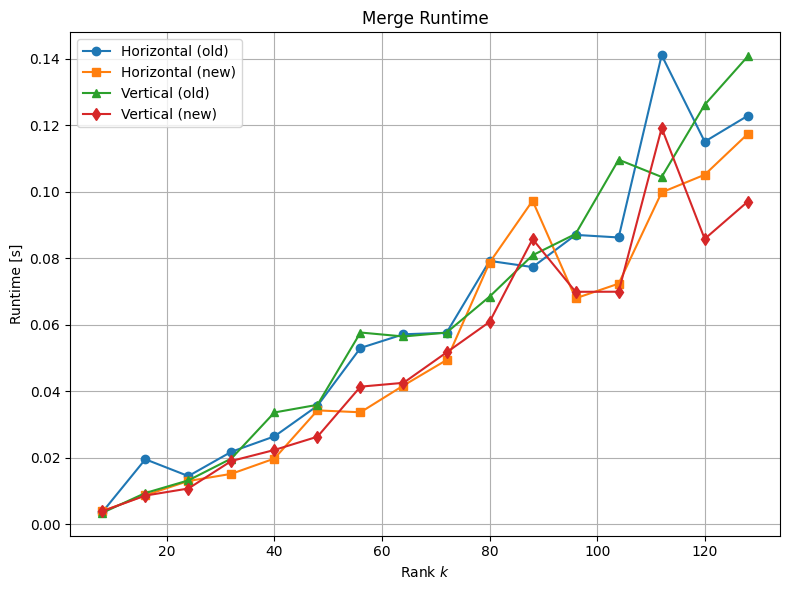

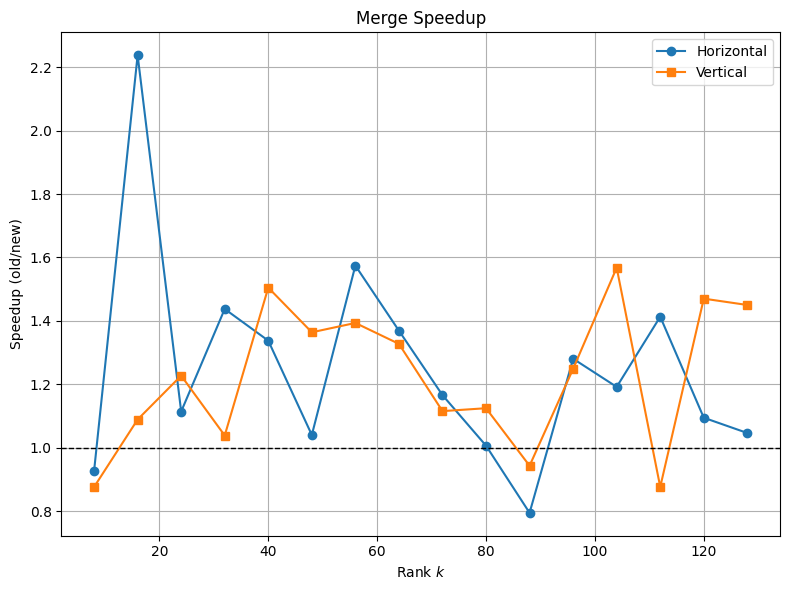

In [ ]:
import json
import plotly.graph_objects as go

# --------------------------------------------------
# Load benchmark data
# --------------------------------------------------

with open("merge_runtime.json", "r") as f:
    data = json.load(f)

k = [d["k"] for d in data]

horizontal_old = [d["horizontal_old"] for d in data]
horizontal_new = [d["horizontal_new"] for d in data]

vertical_old = [d["vertical_old"] for d in data]
vertical_new = [d["vertical_new"] for d in data]

# --------------------------------------------------
# Runtime plot
# --------------------------------------------------

fig_runtime = go.Figure()

fig_runtime.add_trace(
    go.Scatter(
        x=k,
        y=horizontal_old,
        mode="lines+markers",
        name="Horizontal (old)",
        line=dict(width=2),
        marker=dict(size=7),
    )
)

fig_runtime.add_trace(
    go.Scatter(
        x=k,
        y=horizontal_new,
        mode="lines+markers",
        name="Horizontal (new)",
        line=dict(width=2),
        marker=dict(size=7),
    )
)

fig_runtime.add_trace(
    go.Scatter(
        x=k,
        y=vertical_old,
        mode="lines+markers",
        name="Vertical (old)",
        line=dict(width=2),
        marker=dict(size=7),
    )
)

fig_runtime.add_trace(
    go.Scatter(
        x=k,
        y=vertical_new,
        mode="lines+markers",
        name="Vertical (new)",
        line=dict(width=2),
        marker=dict(size=7),
    )
)

fig_runtime.update_layout(
    title="Merge Runtime",
    xaxis_title="Rank $k$",
    yaxis_title="Runtime [s]",
    template="plotly_white",
    width=900,
    height=600,
    font=dict(
        family="Arial",
        size=18,
    ),
    legend=dict(
        font=dict(size=15),
        bordercolor="black",
        borderwidth=1,
        bgcolor="rgba(255,255,255,0.9)",
    ),
    margin=dict(
        l=80,
        r=40,
        t=80,
        b=70,
    ),
)

fig_runtime.update_xaxes(
    showline=True,
    mirror=True,
    linewidth=1.5,
    ticks="outside",
    showgrid=True,
    gridcolor="lightgray",
    gridwidth=0.5,
)

fig_runtime.update_yaxes(
    showline=True,
    mirror=True,
    linewidth=1.5,
    ticks="outside",
    showgrid=True,
    gridcolor="lightgray",
    gridwidth=0.5,
)

fig_runtime.show()
fig_runtime.write_image("merge_runtime.svg")

# --------------------------------------------------
# Speedup plot
# --------------------------------------------------

horizontal_speedup = [
    old / new
    for old, new in zip(horizontal_old, horizontal_new)
]

vertical_speedup = [
    old / new
    for old, new in zip(vertical_old, vertical_new)
]

fig_speedup = go.Figure()

fig_speedup.add_trace(
    go.Scatter(
        x=k,
        y=horizontal_speedup,
        mode="lines+markers",
        name="Horizontal",
        line=dict(width=2),
        marker=dict(size=7),
    )
)

fig_speedup.add_trace(
    go.Scatter(
        x=k,
        y=vertical_speedup,
        mode="lines+markers",
        name="Vertical",
        line=dict(width=2),
        marker=dict(size=7),
    )
)

fig_speedup.add_hline(
    y=1.0,
    line_dash="dash",
    line_color="black",
    line_width=1.5,
)

fig_speedup.update_layout(
    title="Merge Speedup",
    xaxis_title="Rank $k$",
    yaxis_title="Speedup (old/new)",
    template="plotly_white",
    width=900,
    height=600,
    font=dict(
        family="Arial",
        size=18,
    ),
    legend=dict(
        font=dict(size=15),
        bordercolor="black",
        borderwidth=1,
        bgcolor="rgba(255,255,255,0.9)",
    ),
    margin=dict(
        l=80,
        r=40,
        t=80,
        b=70,
    ),
)

fig_speedup.update_xaxes(
    showline=True,
    mirror=True,
    linewidth=1.5,
    ticks="outside",
    showgrid=True,
    gridcolor="lightgray",
    gridwidth=0.5,
)

fig_speedup.update_yaxes(
    showline=True,
    mirror=True,
    linewidth=1.5,
    ticks="outside",
    showgrid=True,
    gridcolor="lightgray",
    gridwidth=0.5,
)

fig_speedup.show()
fig_speedup.write_image("merge_speedup.svg")

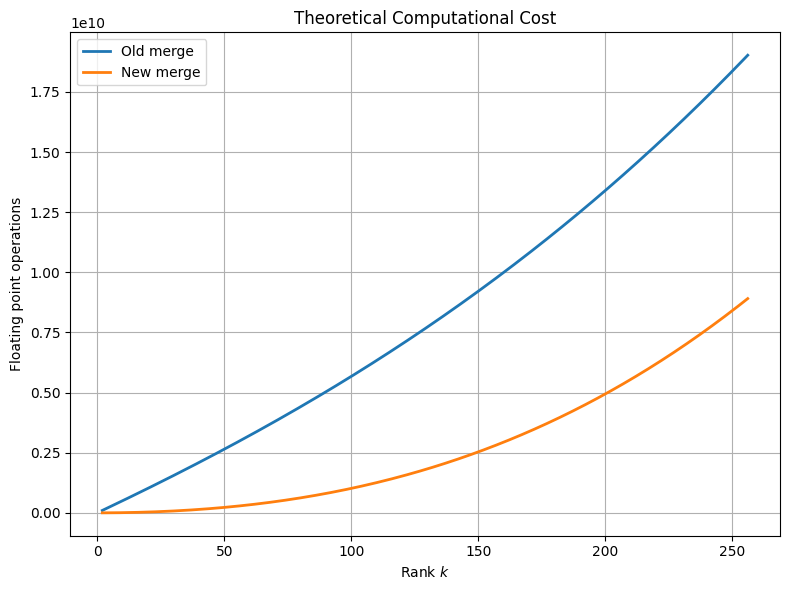

In [ ]:
import json
import plotly.graph_objects as go

# --------------------------------------------------
# Load benchmark data
# --------------------------------------------------

with open("merge_runtime.json", "r") as f:
    data = json.load(f)

k = [d["k"] for d in data]

horizontal_old = [d["horizontal_old"] for d in data]
horizontal_new = [d["horizontal_new"] for d in data]

vertical_old = [d["vertical_old"] for d in data]
vertical_new = [d["vertical_new"] for d in data]

# --------------------------------------------------
# Runtime plot
# --------------------------------------------------

fig_runtime = go.Figure()

fig_runtime.add_trace(
    go.Scatter(
        x=k,
        y=horizontal_old,
        mode="lines+markers",
        name="Horizontal (old)",
    )
)

fig_runtime.add_trace(
    go.Scatter(
        x=k,
        y=horizontal_new,
        mode="lines+markers",
        name="Horizontal (new)",
    )
)

fig_runtime.add_trace(
    go.Scatter(
        x=k,
        y=vertical_old,
        mode="lines+markers",
        name="Vertical (old)",
    )
)

fig_runtime.add_trace(
    go.Scatter(
        x=k,
        y=vertical_new,
        mode="lines+markers",
        name="Vertical (new)",
    )
)

fig_runtime.update_layout(
    title="Merge Runtime",
    xaxis_title="Rank",
    yaxis_title="Runtime [s]",
    template="plotly_white",
    width=900,
    height=600,
    font=dict(
        family="Arial",
        size=18,
    ),
    legend=dict(
        bordercolor="black",
        borderwidth=1,
        bgcolor="rgba(255,255,255,0.9)",
    ),
)

fig_runtime.update_xaxes(
    showline=True,
    mirror=True,
    linewidth=1.5,
    ticks="outside",
    showgrid=True,
    gridcolor="lightgray",
)

fig_runtime.update_yaxes(
    showline=True,
    mirror=True,
    linewidth=1.5,
    ticks="outside",
    showgrid=True,
    gridcolor="lightgray",
)

fig_runtime.show()
fig_runtime.write_image("merge_runtime.svg")

# --------------------------------------------------
# Speedup plot
# --------------------------------------------------

horizontal_speedup = [
    old / new
    for old, new in zip(horizontal_old, horizontal_new)
]

vertical_speedup = [
    old / new
    for old, new in zip(vertical_old, vertical_new)
]

fig_speedup = go.Figure()

fig_speedup.add_trace(
    go.Scatter(
        x=k,
        y=horizontal_speedup,
        mode="lines+markers",
        name="Horizontal",
    )
)

fig_speedup.add_trace(
    go.Scatter(
        x=k,
        y=vertical_speedup,
        mode="lines+markers",
        name="Vertical",
    )
)

fig_speedup.add_hline(
    y=1.0,
    line_dash="dash",
    line_color="black",
)

fig_speedup.update_layout(
    title="Merge Speedup",
    xaxis_title="Rank",
    yaxis_title="Speedup (old/new)",
    template="plotly_white",
    width=900,
    height=600,
    font=dict(
        family="Arial",
        size=18,
    ),
    legend=dict(
        bordercolor="black",
        borderwidth=1,
        bgcolor="rgba(255,255,255,0.9)",
    ),
)

fig_speedup.update_xaxes(
    showline=True,
    mirror=True,
    linewidth=1.5,
    ticks="outside",
    showgrid=True,
    gridcolor="lightgray",
)

fig_speedup.update_yaxes(
    showline=True,
    mirror=True,
    linewidth=1.5,
    ticks="outside",
    showgrid=True,
    gridcolor="lightgray",
)

fig_speedup.show()
fig_speedup.write_image("merge_speedup.svg")

In [37]:
import pandas as pd
import plotly.graph_objects as go
from plotly.colors import qualitative

# =====================================================
# Select residual benchmark files
# =====================================================

selected = [
    "results/2026-08-07_10-12-37.json",
    "results/2026-08-07_10-21-31.json",
    # "results/baca_cpqr.json",
]

# =====================================================
# Initial Frobenius norms (rank = 0)
# Replace the values below
# =====================================================

initial_frob = {
    "baca": 1.0,
    "2026-08-07_10-12-37": 20192069.651868,
    "2026-08-07_10-21-31": 20192069.651868,
    # "baca_cpqr": 1.0,
}

# =====================================================
# Load data
# =====================================================

dfs = []

for f in selected:
    df = load_residual_json(f)
    if not df.empty:
        dfs.append(df)

df = pd.concat(dfs, ignore_index=True)

# =====================================================
# Styles
# =====================================================

palette = qualitative.Dark24

files = df["file"].unique()

color_map = {
    file: palette[i % len(palette)]
    for i, file in enumerate(files)
}

dash_map = {
    0: "solid",
    4: "dash",
    8: "dot",
    16: "dashdot",
    32: "longdash",
    64: "longdashdot",
    128: "solid",
}

marker_map = {
    0: "circle",
    4: "square",
    8: "diamond",
    16: "triangle-up",
    32: "triangle-down",
    64: "cross",
    128: "x",
}

# =====================================================
# Figures
# =====================================================

fig_v = go.Figure()
fig_frob = go.Figure()

for (method, d, L, file), subdf in df.groupby(
    ["method", "d", "L", "file"]
):

    color = color_map[file]
    dash = dash_map.get(d, "solid")
    marker = marker_map.get(d, "circle")

    label = f"{method.upper()}  d={d}"

    # -------------------------------
    # Relative residual
    # -------------------------------

    vdf = (
        subdf[subdf["series"] == "v"]
        .sort_values("rank")
    )

    # -------------------------------
    # Frobenius norm
    # -------------------------------

    fdf = (
        subdf[subdf["series"] == "frob"]
        .sort_values("rank")
        .copy()
    )

    # Add rank-0 Frobenius norm
    if file in initial_frob:

        first = pd.DataFrame({
            "rank": [0],
            "value": [initial_frob[file]],
        })

        fdf = pd.concat([first, fdf], ignore_index=True)

    fig_v.add_trace(
        go.Scatter(
            x=vdf["rank"],
            y=vdf["value"],
            mode="lines+markers",
            name=label,
            line=dict(
                color=color,
                dash=dash,
                width=2,
            ),
            marker=dict(
                color=color,
                symbol=marker,
                size=10,
            ),
        )
    )

    fig_frob.add_trace(
        go.Scatter(
            x=fdf["rank"],
            y=fdf["value"],
            mode="lines+markers",
            name=label,
            line=dict(
                color=color,
                dash=dash,
                width=2,
            ),
            marker=dict(
                color=color,
                symbol=marker,
                size=10,
            ),
        )
    )

# =====================================================
# Layout
# =====================================================

fig_v.update_layout(
    title="Relative residual",
    template="plotly_white",
    width=1400,
    height=700,
    xaxis_title="Rank",
    yaxis_title="Relative residual",
    font=dict(
        family="Arial",
        size=18,
    ),
    legend=dict(
        bordercolor="black",
        borderwidth=1,
        bgcolor="rgba(255,255,255,0.9)",
    ),
)

fig_v.update_yaxes(type="log")
fig_v.update_xaxes(showline=True, mirror=True)
fig_v.update_yaxes(showline=True, mirror=True)

fig_frob.update_layout(
    title="Frobenius norm",
    template="plotly_white",
    width=1400,
    height=700,
    xaxis_title="Rank",
    yaxis_title="Frobenius norm",
    font=dict(
        family="Arial",
        size=18,
    ),
    legend=dict(
        bordercolor="black",
        borderwidth=1,
        bgcolor="rgba(255,255,255,0.9)",
    ),
)

fig_frob.update_yaxes(type="log")
fig_frob.update_xaxes(showline=True, mirror=True)
fig_frob.update_yaxes(showline=True, mirror=True)

fig_v.show()
fig_frob.show()
fig_v.write_image("relative_residual_qr_update.svg")
fig_frob.write_image("frobenius_norm_qr_update.svg")